# Forecasting Models

## Purpose

Having established the presence of a long-term warming trend and confirmed the stationarity properties of the climate anomaly series, the next step is to develop forecasting models capable of predicting future temperature anomalies.

This notebook compares multiple time series forecasting approaches ranging from simple baseline methods to classical statistical forecasting models.

### Objectives

- Develop baseline forecasting models.
- Implement Exponential Smoothing.
- Build ARIMA forecasting models.
- Compare predictive performance.
- Generate future climate forecasts.
- Identify the most accurate forecasting approach.

### Models Evaluated

- Naïve Forecast
- Moving Average Forecast
- Exponential Smoothing
- ARIMA

### Expected Outcome

Determine the forecasting model that best captures the underlying dynamics of global temperature anomalies and provides the most accurate future predictions.

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error
)

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA

from math import sqrt

In [3]:
df = pd.read_csv("/content/monthly_csv.csv")

df["Date"] = pd.to_datetime(df["Date"])

climate = (
    df.groupby("Date")["Mean"]
      .mean()
      .reset_index()
)

climate = climate.sort_values("Date")

climate.set_index(
    "Date",
    inplace=True
)

series = climate["Mean"]

Train-Test Split


In [4]:

train_size = int(
    len(series) * 0.8
)

train = series[:train_size]

test = series[train_size:]

print("Training Size:", len(train))
print("Testing Size:", len(test))

Training Size: 1315
Testing Size: 329


Model 1: Naive Forecast


In [5]:
naive_forecast = np.repeat(
    train.iloc[-1],
    len(test)
)

naive_rmse = sqrt(
    mean_squared_error(
        test,
        naive_forecast
    )
)

print(
    "Naive RMSE:",
    round(naive_rmse,4)
)

Naive RMSE: 0.3058


Model 2: Moving Average


In [7]:

moving_average = np.repeat(
    train.tail(12).mean(),
    len(test)
)

ma_rmse = sqrt(
    mean_squared_error(
        test,
        moving_average
    )
)

print(
    "Moving Average RMSE:",
    round(ma_rmse,4)
)


Moving Average RMSE: 0.3239


Model 3: Exponential Smoothing


In [9]:

exp_model = ExponentialSmoothing(
    train,
    trend="add",
    seasonal=None
)

exp_fit = exp_model.fit()


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [10]:

exp_forecast = exp_fit.forecast(
    len(test)
)

exp_rmse = sqrt(
    mean_squared_error(
        test,
        exp_forecast
    )
)

print(
    "Exponential Smoothing RMSE:",
    round(exp_rmse,4)
)

Exponential Smoothing RMSE: 0.2807


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


Model 4: ARIMA


Because Notebook 03 showed:

I(1)




In [11]:
arima_model = ARIMA(
    train,
    order=(1,1,1)
)

arima_fit = arima_model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [12]:
arima_forecast = arima_fit.forecast(
    steps=len(test)
)

arima_rmse = sqrt(
    mean_squared_error(
        test,
        arima_forecast
    )
)

print(
    "ARIMA RMSE:",
    round(arima_rmse,4)
)

ARIMA RMSE: 0.3318


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


Comparison Table

In [14]:
results = pd.DataFrame({
    "Model":[
        "Naive",
        "Moving Average",
        "Exponential Smoothing",
        "ARIMA"
    ],
    "RMSE":[
        naive_rmse,
        ma_rmse,
        exp_rmse,
        arima_rmse
    ]
})

results.sort_values(
    "RMSE"
)

,Model,RMSE
2,Exponential Smoothing,0.280673
0,Naive,0.305800
1,Moving Average,0.323936
3,ARIMA,0.331778


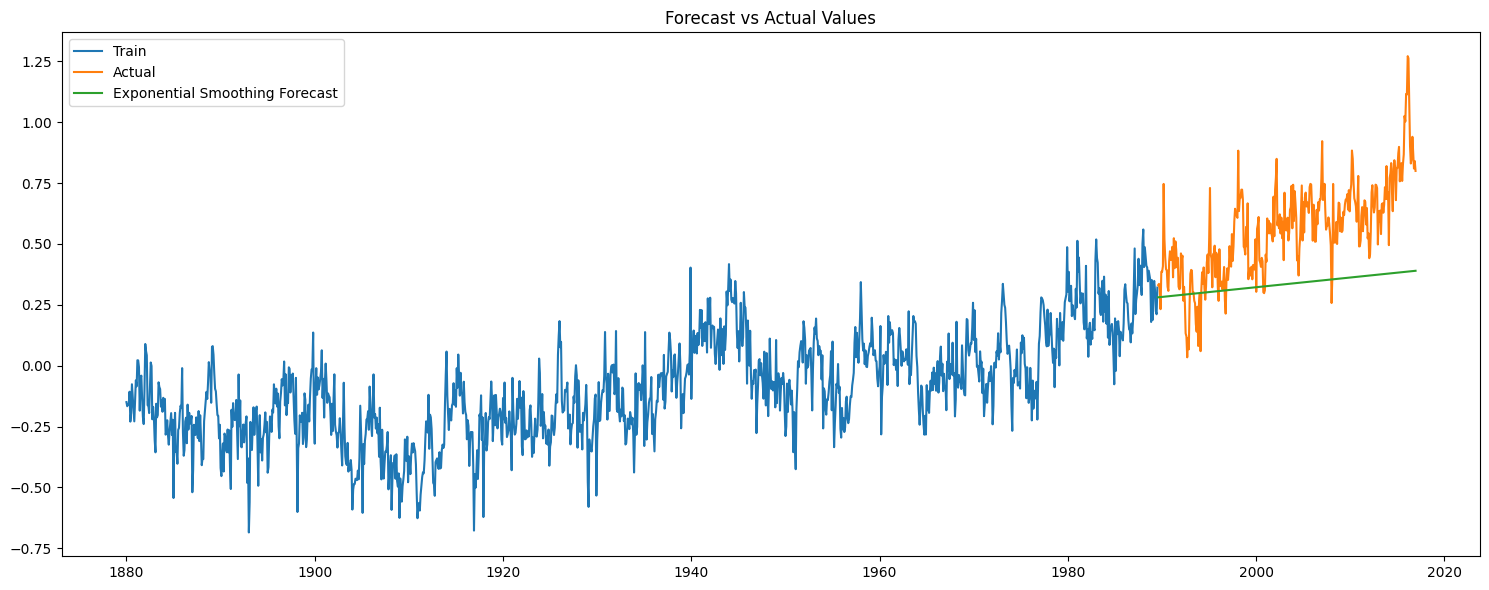

In [15]:
plt.figure(figsize=(15,6))

plt.plot(
    train.index,
    train,
    label="Train"
)

plt.plot(
    test.index,
    test,
    label="Actual"
)

plt.plot(
    test.index,
    exp_forecast,
    label="Exponential Smoothing Forecast"
)

plt.legend()

plt.title(
    "Forecast vs Actual Values"
)

plt.tight_layout()

plt.savefig(
    "forecast_vs_actual.png",
    dpi=300
)

plt.show()

Future Forecast

Fitting best model on full data.

Starting with Exponential Smoothing:

In [16]:


final_model = ExponentialSmoothing(
    series,
    trend="add",
    seasonal=None
)

final_fit = final_model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [17]:
future_forecast = final_fit.forecast(
    24
)

future_forecast

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


,0
1644,0.823939
1645,0.824535
1646,0.825131
1647,0.825727
1648,0.826323
1649,0.826919
1650,0.827516
1651,0.828112
1652,0.828708
1653,0.829304


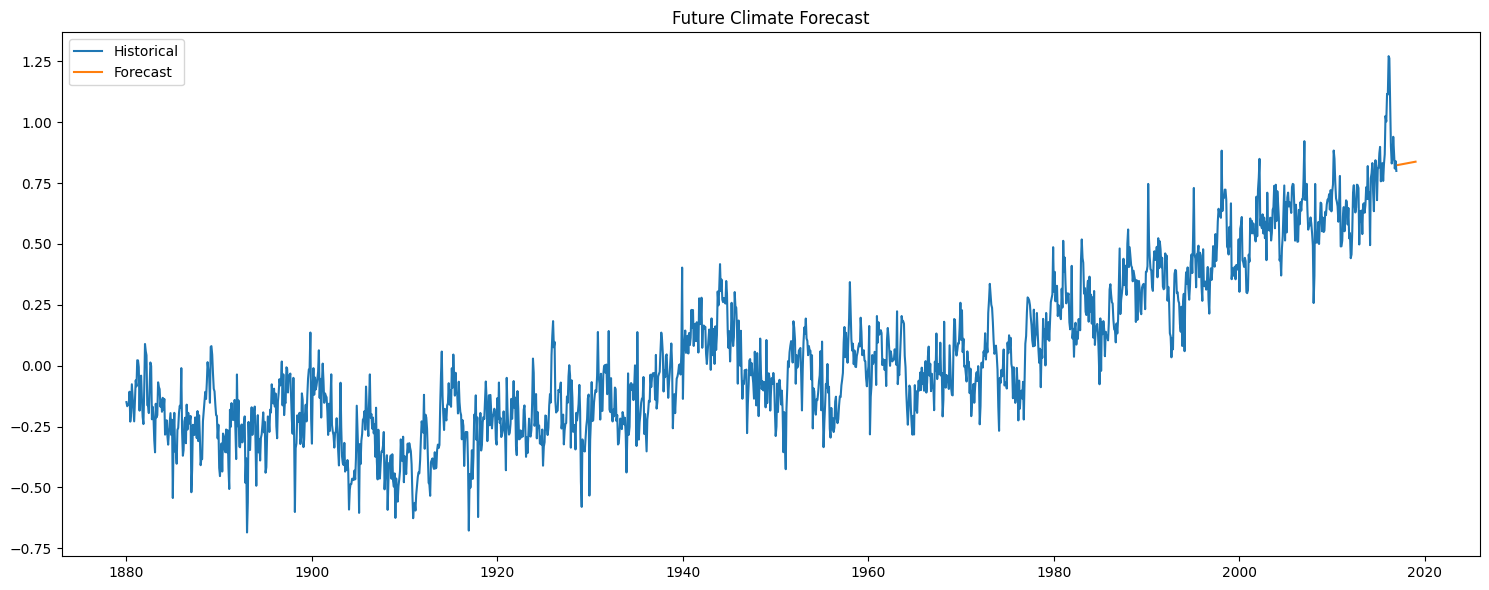

In [18]:
plt.figure(figsize=(15,6))

plt.plot(
    series.index,
    series,
    label="Historical"
)

future_dates = pd.date_range(
    start=series.index[-1],
    periods=25,
    freq="MS"
)[1:]

plt.plot(
    future_dates,
    future_forecast,
    label="Forecast"
)

plt.legend()

plt.title(
    "Future Climate Forecast"
)

plt.tight_layout()

plt.savefig(
    "future_forecast.png",
    dpi=300
)

plt.show()